In [24]:
import numpy as np
import pandas as pd

df = pd.read_csv("data/players_22.csv", low_memory=False)

print(f"Rækker: {df.shape[0]}")
print(f"Kolonner: {df.shape[1]}")
df.head()

Rækker: 19239
Kolonner: 110


,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png


In [25]:
# Vælg de vigtigste numeriske kolonner vi skal bruge
cols = ['short_name', 'age', 'overall', 'potential', 'value_eur', 'wage_eur', 'player_positions']
df_clean = df[cols].copy()

# Fjern rækker med manglende værdier
df_clean = df_clean.dropna()

print(f"Spillere efter oprydning: {len(df_clean)}")
print()

# NumPy beregninger på overall-ratings
ratings = df_clean['overall'].to_numpy()

print(f"Gennemsnitlig rating: {np.mean(ratings):.2f}")
print(f"Højeste rating: {np.max(ratings)}")
print(f"Laveste rating: {np.min(ratings)}")
print(f"Standardafvigelse: {np.std(ratings):.2f}")

# Hvor mange spillere er 'elite' (overall >= 85)?
elite = ratings[ratings >= 85]
print(f"Elite-spillere (85+): {len(elite)}")


Spillere efter oprydning: 19165

Gennemsnitlig rating: 65.76
Højeste rating: 93
Laveste rating: 47
Standardafvigelse: 6.88
Elite-spillere (85+): 97


In [26]:
# Alderfordeling med NumPy
alder = df_clean['age'].to_numpy()

print('=== Aldersanalyse ===')
print(f"Gennemsnitsalder:   {np.mean(alder):.1f} år")
print(f"Yngtse spiller:     {np.min(alder)} år")
print(f"Ældste spiller:     {np.max(alder)} år")


# Opdel spillere i aldersgrupper med np.digitize
grænser = [0, 20, 25, 30, 35, 100]
etiketter = ['U20', '20-25', '25-30', '30-35', '35+']
grupper = np.digitize(alder, bins=grænser) -1

print("=== Spillere per aldersgruppe ===")
for i, etiket in enumerate(etiketter):
    antal = np.sum(grupper == i)
    print(f"{etiket:>6}: {antal} spillere")

print()


# Korrelation mellem alder og rating
korrelation = np.corrcoef(alder, df_clean['overall'].to_numpy()) [0, 1]
print(f"Korrelation alder/rating: {korrelation:.3f}")
print("(+1 = perfekt positiv, -1 = perfekt negativ, 0 = ingen sammenhæng)")


=== Aldersanalyse ===
Gennemsnitsalder:   25.2 år
Yngtse spiller:     16 år
Ældste spiller:     43 år
=== Spillere per aldersgruppe ===
   U20: 2122 spillere
 20-25: 7187 spillere
 25-30: 6074 spillere
 30-35: 3162 spillere
   35+: 620 spillere

Korrelation alder/rating: 0.461
(+1 = perfekt positiv, -1 = perfekt negativ, 0 = ingen sammenhæng)


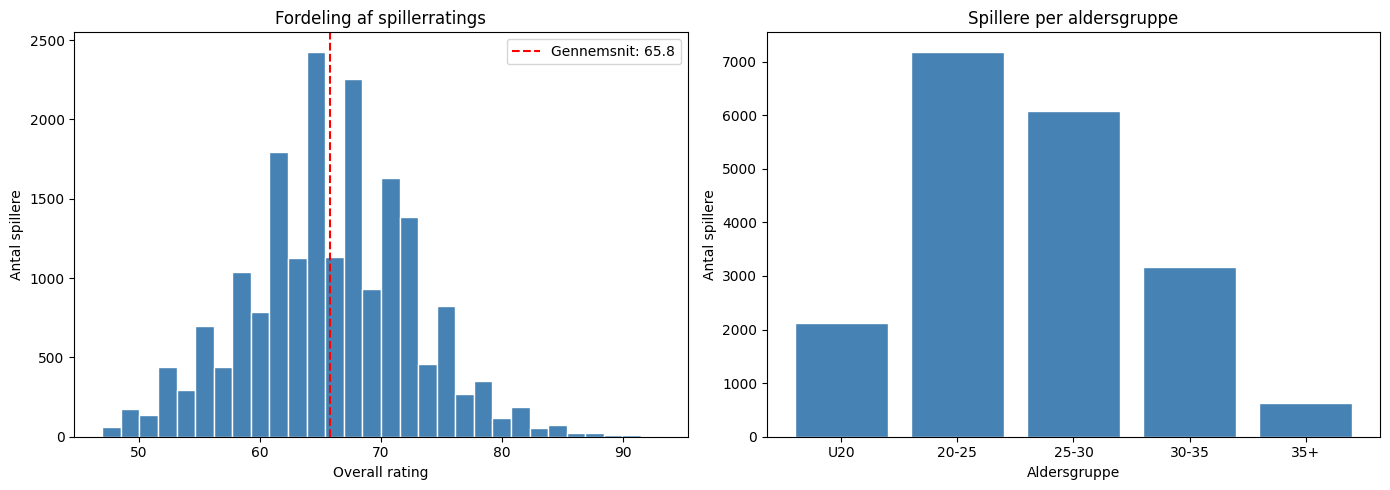

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Plot 1 - Fordeling af ratings
axes[0].hist(df_clean['overall'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Fordeling af spillerratings')
axes[0].set_xlabel('Overall rating')
axes[0].set_ylabel('Antal spillere')
axes[0].axvline(np.mean(ratings), color='red', linestyle='--', label=f'Gennemsnit: {np.mean(ratings):.1f}')
axes[0].legend()

# Plot 2 - Aldersgrupper
antal_per_gruppe = [np.sum(grupper == i) for i in range(len(etiketter))]
axes[1].bar(etiketter, antal_per_gruppe, color='steelblue', edgecolor='white')
axes[1].set_title('Spillere per aldersgruppe')
axes[1].set_xlabel('Aldersgruppe')
axes[1].set_ylabel('Antal spillere')

plt.tight_layout()
plt.savefig('plots/rating_og_alder.png', dpi=150)
plt.show()


